<a href="https://colab.research.google.com/github/MoAbner/LIA1/blob/main/Modelo_Transferlearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1) Verificar se a GPU está ativa

In [2]:
!nvidia-smi

Mon Apr 13 01:18:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# 2) Instalar bibliotecas

In [1]:
!pip install -q ultralytics roboflow

# 3) Importações

In [3]:
from ultralytics import YOLO
from roboflow import Roboflow
from google.colab import files
from ultralytics import YOLO
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import os
import glob


# 4) Baixar o dataset do Roboflow

In [4]:
rf = Roboflow(api_key="iUnkKgeZNWCGTIJhPJ7E")

project = rf.workspace("brad-dwyer").project("wildfire-smoke")
version = project.version(1)
dataset = version.download("yolo26")

print("Dataset salvo em:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...
Dataset salvo em: /content/Wildfire-Smoke-1


# 5) Carregar modelo pré-treinado


In [5]:
model = YOLO("yolo26n.pt")

# 6) Treinar o modelo

In [6]:
resultado_treino = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=25,
    imgsz=640,
    batch=16,
    workers=2,
    project="deteccao_fumaca",
    name="yolo26n_fumaca"
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Wildfire-Smoke-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26n_fumaca2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

# 7) Carregar o melhor modelo treinado

In [7]:
melhor_modelo = YOLO("/content/runs/detect/deteccao_fumaca/yolo26n_fumaca/weights/best.pt")

# 8) Validar o modelo

In [8]:
metricas = melhor_modelo.val(
    data=f"{dataset.location}/data.yaml"
)

print(metricas)


Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1268.2±347.0 MB/s, size: 34.2 KB)
val: Scanning /content/Wildfire-Smoke-1/valid/labels.cache... 147 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 147/147 41.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 4.1it/s 2.5s
                   all        147        147      0.884      0.694      0.852      0.479
Speed: 3.0ms preprocess, 5.7ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /content/runs/detect/val2
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fb0387ea3c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(

# 9) Fazer inferência nas imagens de teste

In [9]:
resultados = melhor_modelo.predict(
    source=f"{dataset.location}/test/images",
    conf=0.25,
    save=True
)


image 1/74 /content/Wildfire-Smoke-1/test/images/ck0kcoc8ik6ni0848clxs0vif_jpeg.rf.8b4629777ffe1d349cc970ee8af59eac.jpg: 480x640 2 smokes, 63.1ms
image 2/74 /content/Wildfire-Smoke-1/test/images/ck0kd4afx8g470701watkwxut_jpeg.rf.bb5a1f2c2b04be20c948fd3c5cec33ff.jpg: 480x640 2 smokes, 10.8ms
image 3/74 /content/Wildfire-Smoke-1/test/images/ck0kdhymna0b10721v4wntit8_jpeg.rf.a08e34d04fb672ce6cf8e94e810ec81d.jpg: 480x640 1 smoke, 11.3ms
image 4/74 /content/Wildfire-Smoke-1/test/images/ck0kepbs9kdym0848hgpcf3y9_jpeg.rf.d0a63becb54a83b6b026f4b38a42933b.jpg: 480x640 1 smoke, 12.4ms
image 5/74 /content/Wildfire-Smoke-1/test/images/ck0kewsaha6hh07215jgx1bp2_jpeg.rf.1a375d20560d0de016bb524921f7b2a9.jpg: 480x640 1 smoke, 10.6ms
image 6/74 /content/Wildfire-Smoke-1/test/images/ck0kfhu4n8q7f0701ixmonyig_jpeg.rf.a3cc5282520b3bac90718bdd5528bd76.jpg: 480x640 1 smoke, 10.9ms
image 7/74 /content/Wildfire-Smoke-1/test/images/ck0kfjen48qhj0701wjkosmel_jpeg.rf.49b365cc7135deee1332e6657401abc5.jpg: 480x64

# 10) Exportar o modelo treinado

In [10]:
melhor_modelo.export(format="onnx")

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/content/runs/detect/deteccao_fumaca/yolo26n_fumaca/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.91...


Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.


ONNX: export success ✅ 1.9s, saved as '/content/runs/detect/deteccao_fumaca/yolo26n_fumaca/weights/best.onnx' (9.4 MB)

Export complete (2.2s)
Results saved to /content/runs/detect/deteccao_fumaca/yolo26n_fumaca/weights
Predict:         yolo predict task=detect model=/content/runs/detect/deteccao_fumaca/yolo26n_fumaca/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/runs/detect/deteccao_fumaca/yolo26n_fumaca/weights/best.onnx imgsz=640 data=/content/Wildfire-Smoke-1/data.yaml  
Visualize:       https://netron.app


'/content/runs/detect/deteccao_fumaca/yolo26n_fumaca/weights/best.onnx'

In [11]:
from google.colab import files
files.download("/content/runs/detect/deteccao_fumaca/yolo26n_fumaca/weights/best.onnx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
from google.colab import files
files.download("/content/runs/detect/deteccao_fumaca/yolo26n_fumaca/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Envie uma imagem do seu computador:


Saving WILDFIRE_3.avif to WILDFIRE_3 (4).avif

image 1/1 /content/WILDFIRE_3 (4).avif: 320x640 (no detections), 60.8ms
Speed: 2.9ms preprocess, 60.8ms inference, 0.4ms postprocess per image at shape (1, 3, 320, 640)
Results saved to /content/runs/detect/predict7
Detecções encontradas: 0


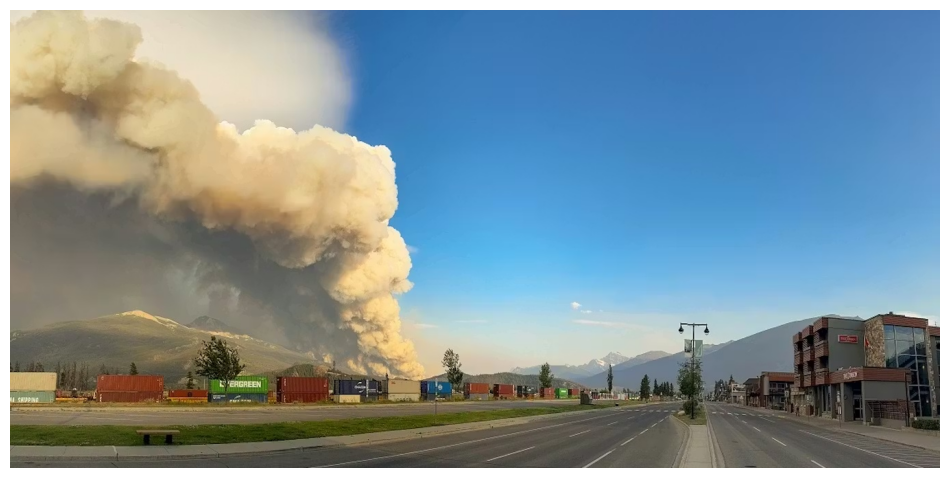

In [13]:
modelo = YOLO("/content/runs/detect/deteccao_fumaca/yolo26n_fumaca/weights/best.pt")

print("Envie uma imagem do seu computador:")
arquivos = files.upload()

nome_arquivo = list(arquivos.keys())[0]

resultados = modelo.predict(
    source=nome_arquivo,
    conf=0.05,
    save=True
)

quantidade = len(resultados[0].boxes)
print(f"Detecções encontradas: {quantidade}")

pasta_saida = str(resultados[0].save_dir)
arquivos_saida = glob.glob(os.path.join(pasta_saida, "*"))
imagem_resultado = arquivos_saida[0]

imagem = PILImage.open(imagem_resultado)

plt.figure(figsize=(12, 8))
plt.imshow(imagem)
plt.axis("off")
plt.show()